In [1]:
# read the table, plot the top 10 most significant and not redundant functions

In [2]:
import pandas, numpy

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(1/3), 9*(4/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
enrichments_file = '/Users/adrian/research/bmcbf/016.saudarkrokur/results/deseq2/clusterProfiler_enrichments.h2.tsv'

In [5]:
df = pandas.read_csv(enrichments_file, sep='\t')
df

,Cluster,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
1,KO vs WT up,R-DME-1428517,Aerobic respiration and respiratory electron t...,62/283,205/4716,0.302439,5.039938,14.941714,4.170734e-29,1.405537e-26,1.141464e-26,35279/32007/50246/42759/41359/32989/44390/4540...,62
2,KO vs WT up,R-DME-611105,Respiratory electron transport,36/283,121/4716,0.297521,4.957977,11.143160,9.811188e-17,1.653185e-14,1.342584e-14,35279/50246/41359/32989/44390/45401/44228/4420...,36
3,KO vs WT up,R-DME-163210,Formation of ATP by chemiosmotic coupling,13/283,16/4716,0.812500,13.539753,12.693612,4.778271e-14,4.025693e-12,3.269343e-12,42759/39143/43507/43693/41845/44046/37931/4229...,13
4,KO vs WT up,R-DME-8949613,Cristae formation,13/283,16/4716,0.812500,13.539753,12.693612,4.778271e-14,4.025693e-12,3.269343e-12,42759/39143/43507/43693/41845/44046/37931/4229...,13
5,KO vs WT up,R-DME-1592230,Mitochondrial biogenesis,14/283,21/4716,0.666667,11.109541,11.730283,4.572501e-13,3.081865e-11,2.502843e-11,42759/39143/43507/43693/41845/44046/37931/4229...,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,h2low vs WT up,R-DME-9749641,Aspirin ADME,4/76,43/4716,0.093023,5.772338,4.023057,4.777007e-03,4.203766e-02,3.519900e-02,42336/37275/39392/34279,4
233,h2low vs WT down,R-DME-3371497,HSP90 chaperone cycle for steroid hormone rece...,5/24,51/4716,0.098039,19.264706,9.378630,4.407310e-06,5.641357e-04,4.824845e-04,44920/48581/318231/26067074/26067075,5
234,h2low vs WT down,R-DME-9646399,Aggrephagy,3/24,37/4716,0.081081,15.932432,6.521123,8.034454e-04,3.595282e-02,3.074912e-02,318231/26067074/26067075,3
235,h2low vs WT down,R-DME-6811442,Intra-Golgi and retrograde Golgi-to-ER traffic,5/24,152/4716,0.032895,6.463816,4.896801,8.426441e-04,3.595282e-02,3.074912e-02,37538/43671/318231/26067074/26067075,5


In [6]:
contrasts = []
for element in df['Cluster']:
    if element not in contrasts:
        contrasts.append(element)

print(contrasts)

['KO vs WT up', 'KO vs WT down', 'h2high vs WT up', 'h2high vs WT down', 'h2high vs KO up', 'h2high vs KO down', 'h2low vs WT up', 'h2low vs WT down']


In [7]:
terms_to_use = []
for contrast in contrasts:
    
    print(contrast)
    sub = df[df['Cluster'] == contrast]
    all_observed_gene_lists = []
    contrast_terms = []
    
    for index, row in sub.iterrows():
        
        
        genes = row['geneID'].split('/')
        print('\t', row['ID'], row['Description'], len(genes))
        
        # checking the overlap
        overlap = False
        max_overlap = 0
        for element in all_observed_gene_lists:
            intersect = list(set(element) & set(genes))
            relative_intersect = len(intersect)/len(genes)
            #print('\t\t\t intersect is', len(intersect), relative_intersect)
            if max_overlap < relative_intersect:
                max_overlap = relative_intersect
            if relative_intersect > 0.9:
                overlap=True
            
        all_observed_gene_lists.append(genes)

        #print('\t', overlap)
        #print()
        if overlap == False:
            print('\t accepting', row['ID'], row['Description'], 'because overlap is', max_overlap)
            if len(contrast_terms) < 10:
                contrast_terms.append(row['ID'])
        else:
            print('\t rejecting', row['ID'], row['Description'], 'because overlap is', max_overlap)
        print()

    # end of contrast
    terms_to_use.append(contrast_terms)
    print()

KO vs WT up
	 R-DME-1428517 Aerobic respiration and respiratory electron transport 62
	 accepting R-DME-1428517 Aerobic respiration and respiratory electron transport because overlap is 0

	 R-DME-611105 Respiratory electron transport 36
	 rejecting R-DME-611105 Respiratory electron transport because overlap is 1.0

	 R-DME-163210 Formation of ATP by chemiosmotic coupling 13
	 rejecting R-DME-163210 Formation of ATP by chemiosmotic coupling because overlap is 1.0

	 R-DME-8949613 Cristae formation 13
	 rejecting R-DME-8949613 Cristae formation because overlap is 1.0

	 R-DME-1592230 Mitochondrial biogenesis 14
	 rejecting R-DME-1592230 Mitochondrial biogenesis because overlap is 0.9285714285714286

	 R-DME-9837999 Mitochondrial protein degradation 24
	 accepting R-DME-9837999 Mitochondrial protein degradation because overlap is 0.7083333333333334

	 R-DME-70263 Gluconeogenesis 10
	 accepting R-DME-70263 Gluconeogenesis because overlap is 0

	 R-DME-71387 Metabolism of carbohydrates 29


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_6799/1154951636.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  matplotlib.pyplot.tight_layout()


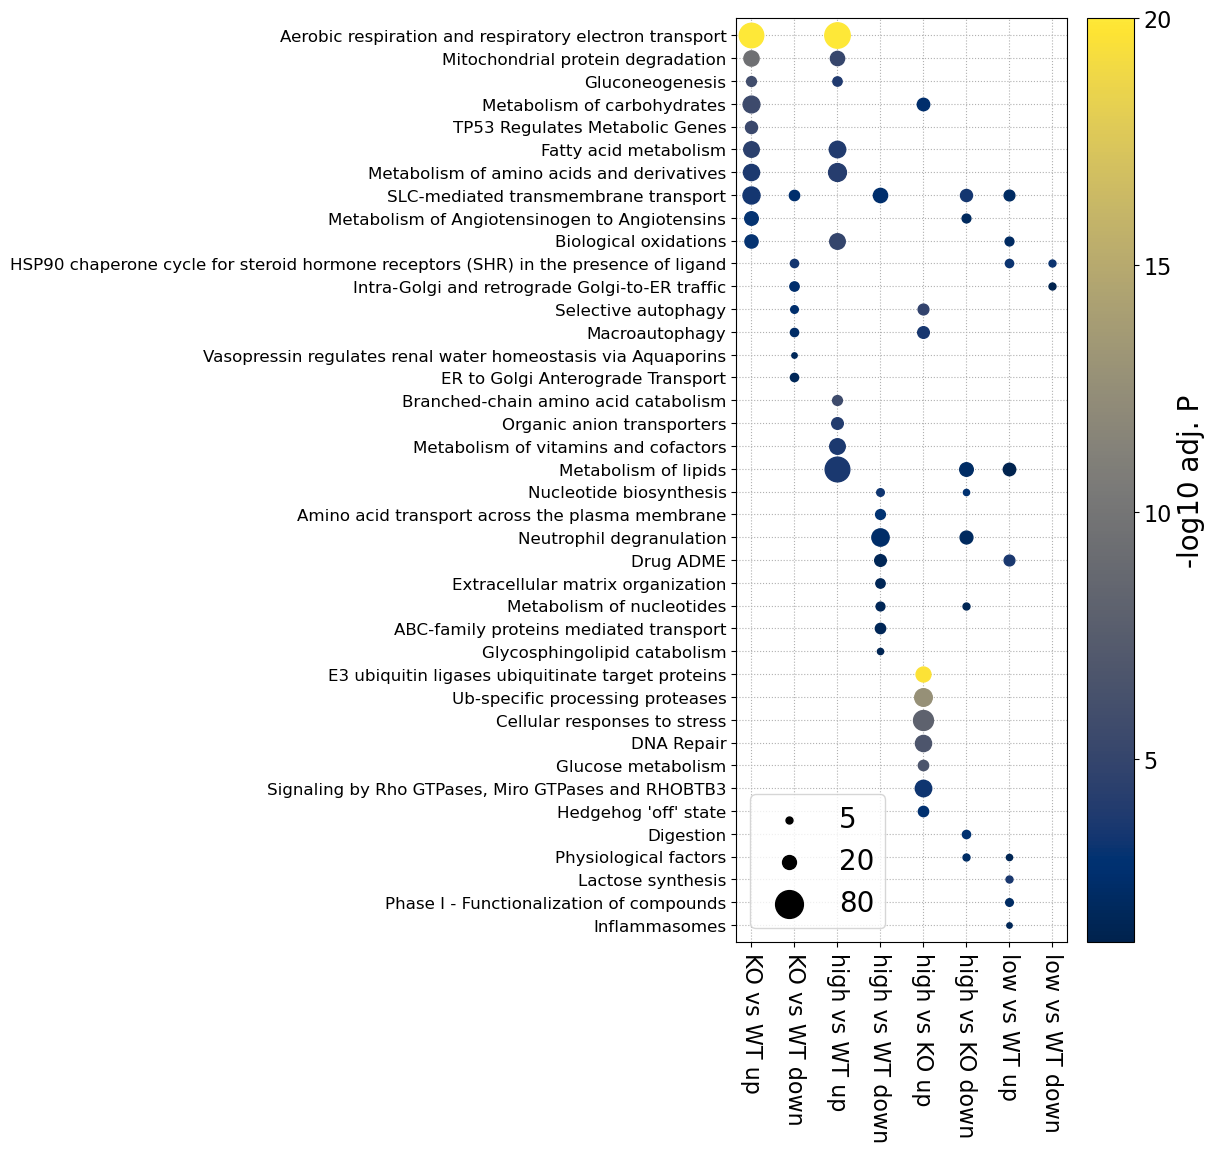

In [10]:
terms_used_so_far = {}
depth = 0
for i in range(len(terms_to_use)):
    for j in range(len(terms_to_use[i])):
       
        element = terms_to_use[i][j]
        
        if element in terms_used_so_far.keys():
            location = terms_used_so_far[element]
        else:
            depth = depth - 1
            location = depth

        # define color
        adjp = -numpy.log10(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['p.adjust'].values[0])
        #print(element, adjp)

        # define size
        thesize = int(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['GeneRatio'].values[0].split('/')[0])
        
        # make a point        
        matplotlib.pyplot.scatter(i, location, s=thesize*5, c=adjp, zorder=9999, cmap='cividis', vmin=-numpy.log10(0.05), vmax=20)

        terms_used_so_far[element] = location


matplotlib.pyplot.colorbar(label='-log10 adj. P', ticks=[5, 10, 15, 20])

# close the figure
a = []; b = []
for element in terms_used_so_far.keys():
    description = list(df[df['ID'] == element]['Description'].values)[0]
    a.append(description)
    b.append(terms_used_so_far[element])

for area in 5*numpy.array([5, 20, 80]):
    matplotlib.pyplot.scatter([], [], c='black', edgecolor=None, s=area, label=str(int(area/5)))
matplotlib.pyplot.legend()

matplotlib.pyplot.yticks(b, a, fontsize=12)
matplotlib.pyplot.xticks([0, 1, 2, 3, 4, 5, 6, 7], 
                         ['KO vs WT up', 'KO vs WT down', 'high vs WT up', 'high vs WT down', 'high vs KO up', 'high vs KO down', 'low vs WT up', 'low vs WT down'], 
                         rotation=-90)
 
# ko vs wt
# high vs wt
# high vs ko
# low vs wt

matplotlib.pyplot.ylim(-40.75, -0.25)
matplotlib.pyplot.grid(ls=':')
matplotlib.pyplot.tight_layout()

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('enrichment.svg')